In [1]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

import mistsim.plotting as msplt

%matplotlib widget

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [2]:
results_dir = Path("results")

# The three runs to compare, in order of increasing coverage
runs = [
    "mars-csa2022-dip-nv-dip",
    "mars-csa2022-dip-mars-mono-analytic-nv-dip-nv-mono-analytic",
    "mars-csa2022-dip-mars-mono-analytic-nv-dip-nv-mono-analytic"
    "-alma-csa2022-dip-alma-mono-analytic",
]
labels = [
    "MARS+NV dip",
    "MARS+NV dip+mono",
    "MARS+NV+ALMA dip+mono",
]

x_recs = []
x_stds = []
x_true = None
lmax = None

for run in runs:
    d = np.load(results_dir / f"{run}.npz")
    x_recs.append(d["x_rec"])
    x_stds.append(d["std_alm"])
    if x_true is None:
        x_true = d["x_true"]
        lmax = int(d["lmax"])

print(f"lmax = {lmax}, {len(x_recs)} runs loaded")
for lab, run in zip(labels, runs):
    print(f"  {lab}: {run}")

lmax = 179, 3 runs loaded
  MARS+NV dip: mars-csa2022-dip-nv-dip
  MARS+NV dip+mono: mars-csa2022-dip-mars-mono-analytic-nv-dip-nv-mono-analytic
  MARS+NV+ALMA dip+mono: mars-csa2022-dip-mars-mono-analytic-nv-dip-nv-mono-analytic-alma-csa2022-dip-alma-mono-analytic


In [ ]:
msplot

In [ ]:
# Main comparison grid: true + recovered maps + fractional residuals
fig = msplt.plot_comparison_grid(
    x_true, x_recs, labels, lmax, plot_lmax=10,
    nside=128, plot_galactic=True, frac_range=1., ratio=True,
)
fig.suptitle(
    "Map Recovery Comparison (l ≤ 10)", fontsize=16, y=1.02,
)
plt.show()

In [ ]:
# Same grid but with absolute residuals
fig = msplt.plot_comparison_grid(
    x_true, x_recs, labels, lmax, plot_lmax=10,
    nside=128, plot_galactic=True, ratio=False,
)
fig.suptitle(
    "Map Recovery Comparison — Absolute Residuals (l ≤ 10)",
    fontsize=16, y=1.02,
)
plt.show()


  MARS+NV dip


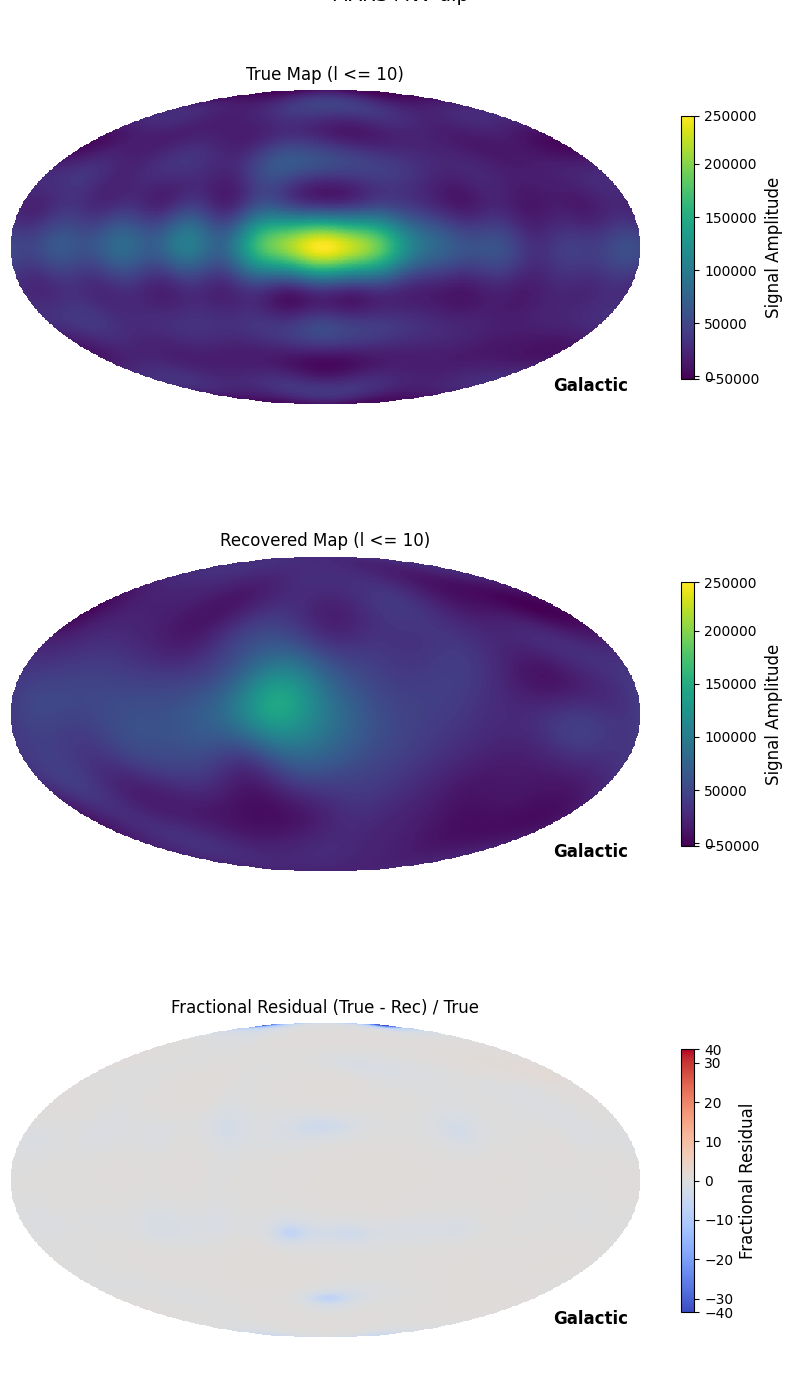


  MARS+NV dip+mono


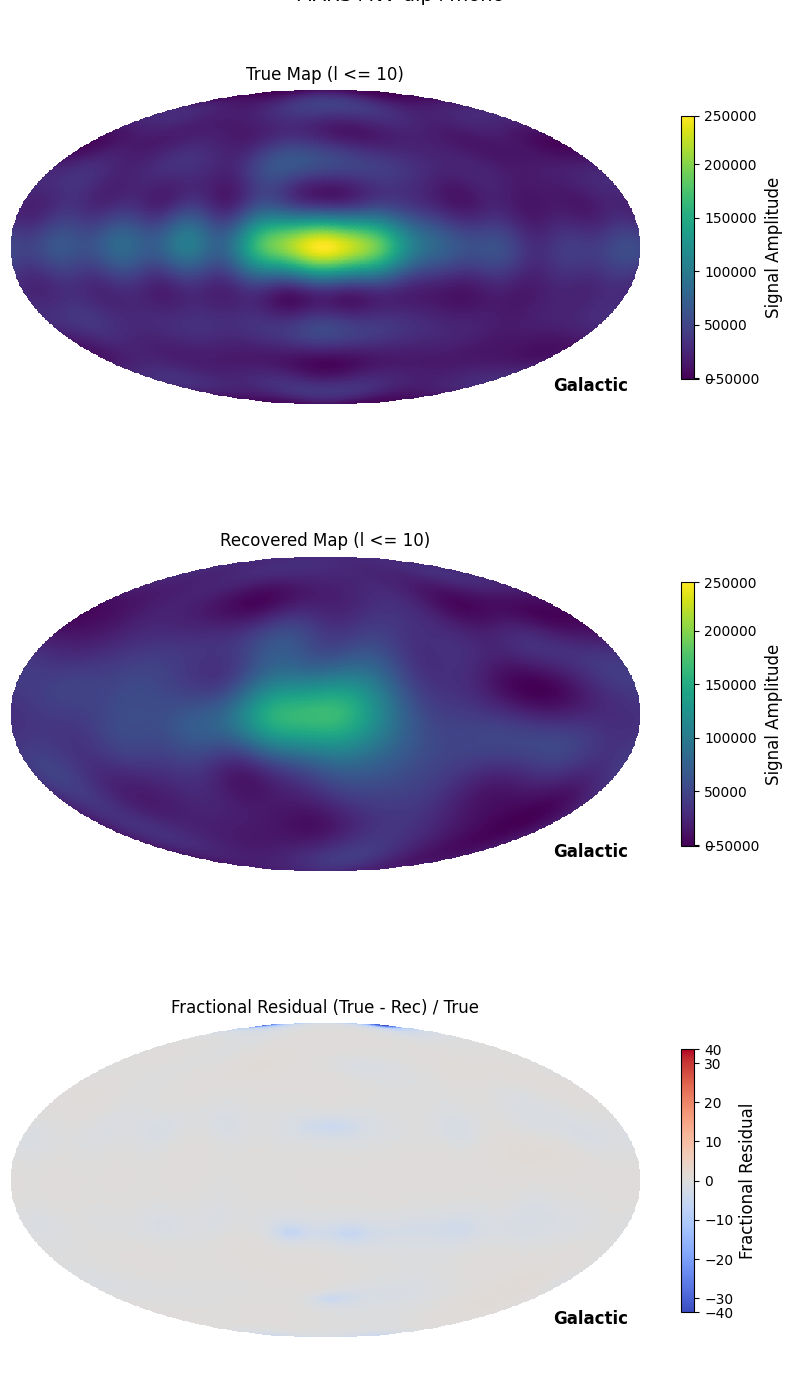


  MARS+NV+ALMA dip+mono


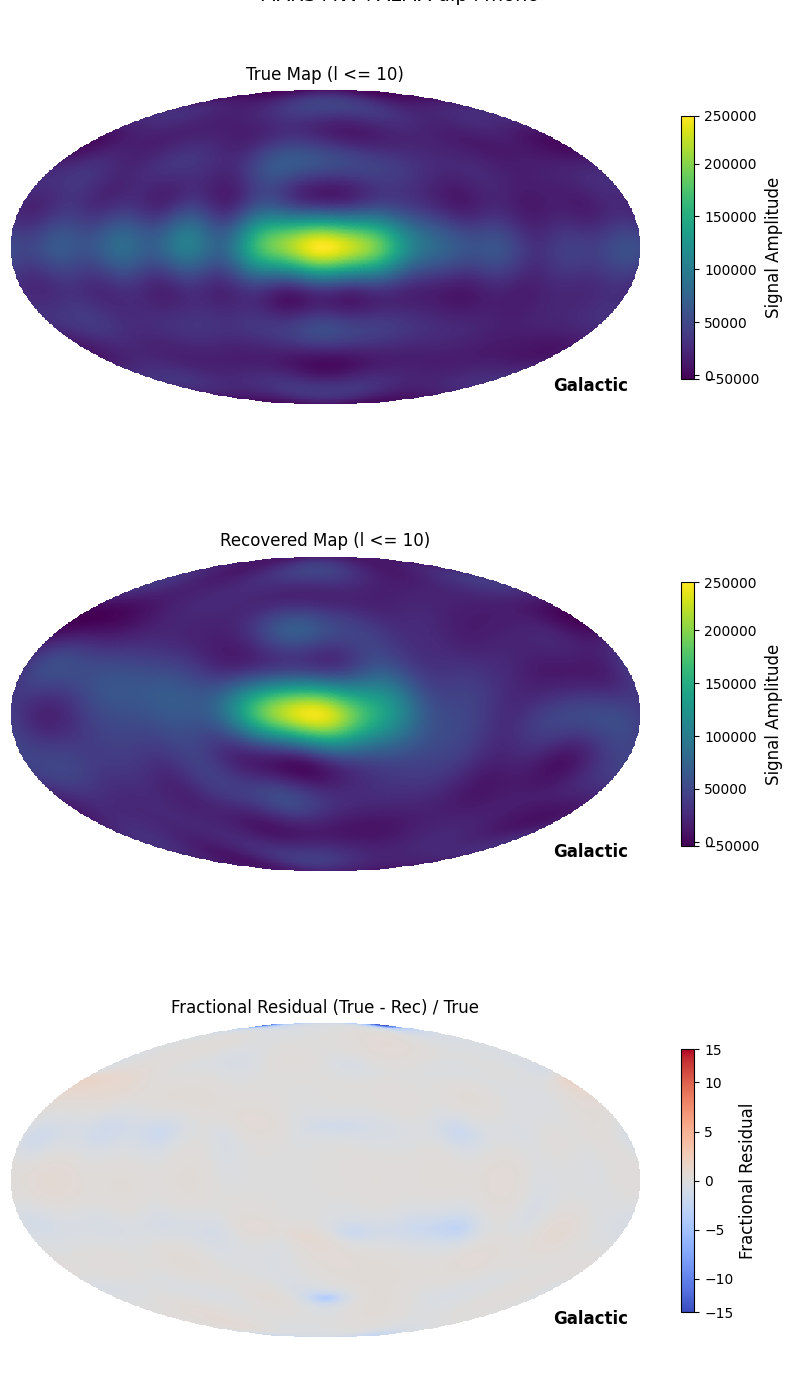

In [6]:
# Individual maps & fractional residuals per run
for lab, xr in zip(labels, x_recs):
    print(f"\n{'='*60}")
    print(f"  {lab}")
    print(f"{'='*60}")
    fig = msplt.plot_maps_and_residuals(
        x_true, xr, lmax, 10,
        nside=128, plot_galactic=True, ratio=True,
    )
    fig.suptitle(lab, fontsize=14, y=1.01)
    plt.show()

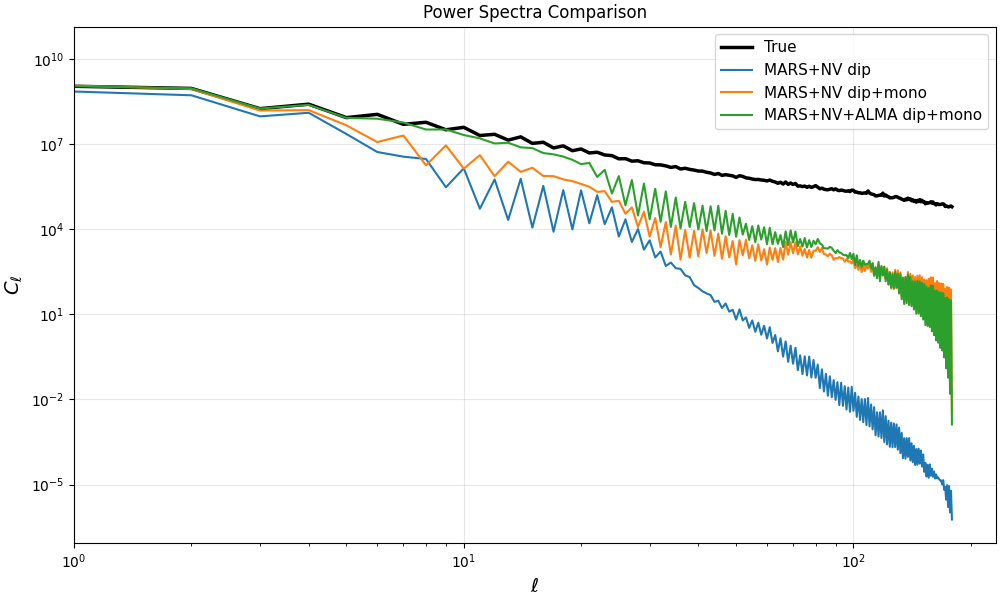

In [7]:
# Overlay power spectra
cl_true = hp.alm2cl(x_true)
ell = np.arange(len(cl_true))

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
ax.plot(ell, cl_true, "k-", lw=2.5, label="True")
colors = ["C0", "C1", "C2"]
for lab, xr, c in zip(labels, x_recs, colors):
    ax.plot(ell, hp.alm2cl(xr), color=c, lw=1.5, label=lab)
ax.set_yscale("log")
if len(ell) > 100:
    ax.set_xscale("log")
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$C_\ell$", fontsize=14)
ax.set_title("Power Spectra Comparison")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(left=1)
plt.show()

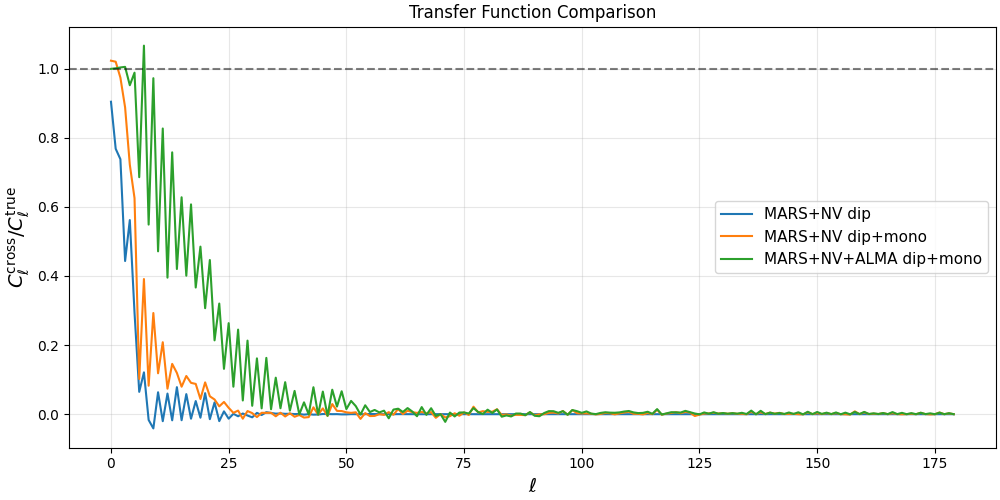

In [8]:
# Overlay transfer functions
cl_true = hp.alm2cl(x_true)
valid = cl_true > 0

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
colors = ["C0", "C1", "C2"]
for lab, xr, c in zip(labels, x_recs, colors):
    cl_cross = hp.alm2cl(x_true, xr)
    tf = np.zeros_like(cl_true)
    tf[valid] = cl_cross[valid] / cl_true[valid]
    ax.plot(np.arange(len(tf)), tf, color=c, lw=1.5, label=lab)
ax.axhline(1, color="k", ls="--", alpha=0.5)
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$C_\ell^{\rm cross} / C_\ell^{\rm true}$", fontsize=14)
ax.set_title("Transfer Function Comparison")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.show()